# BioRED — Exploração e Limpeza de Dados
**NLP + BioInformática — UFPB 2026**

Este notebook realiza:
1. Carregamento dos splits Train / Dev / Test
2. Exploração estrutural do formato BioC-JSON
3. Construção dos DataFrames de documentos, entidades e relações
4. Análise exploratória completa (EDA)
5. Limpeza e pré-processamento
6. Exportação dos artefatos limpos para as próximas etapas

## 1. Setup e Imports

In [7]:
import os
import re
import json
import zipfile
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns', None)

# Paleta consistente com o tema do projeto
CORES = ['#5B8DEF', '#A259FF', '#FF6B6B', '#43C6AC', '#F7971E', '#FFD700']
sns.set_theme(style='darkgrid', palette=CORES)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print(' Imports OK')

 Imports OK


## 2. Carregamento dos Dados

### 2.1 Montagem do Drive e extração do ZIP

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
CAMINHO_ZIP    = '/content/drive/MyDrive/NLP-BioInfo/NLP-BioInfo/arquivos/BIORED.zip'
PASTA_EXTRACAO = '/content/biored_extraido'
PASTA_SAIDA    = '/content/drive/MyDrive/NLP-BioInfo/NLP-BioInfo/dados_limpos'

#CAMINHO_ZIP    = '/content/drive/MyDrive/NLP-BioInfo/arquivos/BIORED.zip'
#PASTA_EXTRACAO = '/content/biored_extraido'
#PASTA_SAIDA    = '/content/drive/MyDrive/NLP-BioInfo/dados_limpos'

os.makedirs(PASTA_EXTRACAO, exist_ok=True)
os.makedirs(PASTA_SAIDA, exist_ok=True)

with zipfile.ZipFile(CAMINHO_ZIP, 'r') as zf:
    zf.extractall(PASTA_EXTRACAO)

arquivos = list(Path(PASTA_EXTRACAO).rglob('*'))
print(f'Total de arquivos extraídos: {len(arquivos)}')
for a in arquivos:
    print(' ', a)

Total de arquivos extraídos: 10
  /content/biored_extraido/BioRED
  /content/biored_extraido/BioRED/Dev.PubTator
  /content/biored_extraido/BioRED/Train.BioC.JSON
  /content/biored_extraido/BioRED/Test.BioC.XML
  /content/biored_extraido/BioRED/Test.BioC.JSON
  /content/biored_extraido/BioRED/Test.PubTator
  /content/biored_extraido/BioRED/Dev.BioC.JSON
  /content/biored_extraido/BioRED/Train.BioC.XML
  /content/biored_extraido/BioRED/Dev.BioC.XML
  /content/biored_extraido/BioRED/Train.PubTator


### 2.2 Carregamento dos JSONs BioC

In [10]:
ARQUIVO_TRAIN = f'{PASTA_EXTRACAO}/BioRED/Train.BioC.JSON'
ARQUIVO_DEV   = f'{PASTA_EXTRACAO}/BioRED/Dev.BioC.JSON'
ARQUIVO_TEST  = f'{PASTA_EXTRACAO}/BioRED/Test.BioC.JSON'

def carregar_bioc_json(caminho):
    """Carrega um arquivo BioC-JSON e retorna a lista de documentos."""
    with open(caminho, 'r', encoding='utf-8') as f:
        dados = json.load(f)
    if isinstance(dados, dict) and 'documents' in dados:
        return dados['documents']
    elif isinstance(dados, list):
        return dados
    raise ValueError(f'Formato não reconhecido: {caminho}')

docs_train = carregar_bioc_json(ARQUIVO_TRAIN)
docs_dev   = carregar_bioc_json(ARQUIVO_DEV)
docs_test  = carregar_bioc_json(ARQUIVO_TEST)

print(f'Train : {len(docs_train):>4} documentos')
print(f'Dev   : {len(docs_dev):>4} documentos')
print(f'Test  : {len(docs_test):>4} documentos')
print(f'Total : {len(docs_train)+len(docs_dev)+len(docs_test):>4} documentos')

Train :  400 documentos
Dev   :  100 documentos
Test  :  100 documentos
Total :  600 documentos


### 2.3 Inspeção da estrutura de um documento

In [11]:
exemplo = docs_train[0]
print('Chaves do documento:', list(exemplo.keys()))
print('ID do documento    :', exemplo.get('id'))
print('Nº de passages     :', len(exemplo.get('passages', [])))
print('Nº de relations    :', len(exemplo.get('relations', [])))

print('\n--- Primeira passage (trecho) ---')
print(json.dumps(exemplo['passages'][0], indent=2, ensure_ascii=False)[:1500])

if exemplo.get('relations'):
    print('\n--- Primeira relação ---')
    print(json.dumps(exemplo['relations'][0], indent=2, ensure_ascii=False))

Chaves do documento: ['id', 'passages', 'relations']
ID do documento    : 10491763
Nº de passages     : 2
Nº de relations    : 3

--- Primeira passage (trecho) ---
{
  "offset": 0,
  "text": "Hepatocyte nuclear factor-6: associations between genetic variability and type II diabetes and between genetic variability and estimates of insulin secretion.",
  "annotations": [
    {
      "id": "0",
      "infons": {
        "identifier": "3175",
        "type": "GeneOrGeneProduct"
      },
      "text": "Hepatocyte nuclear factor-6",
      "locations": [
        {
          "offset": 0,
          "length": 27
        }
      ]
    },
    {
      "id": "1",
      "infons": {
        "identifier": "D003924",
        "type": "DiseaseOrPhenotypicFeature"
      },
      "text": "type II diabetes",
      "locations": [
        {
          "offset": 74,
          "length": 16
        }
      ]
    },
    {
      "id": "2",
      "infons": {
        "identifier": "3630",
        "type": "GeneOrGenePr

## 3. Construção dos DataFrames

### 3.1 Funções de parsing

In [12]:
def extrair_documentos(docs_lista, split_nome):
    """Extrai informações de nível de documento."""
    registros = []
    for doc in docs_lista:
        passages = doc.get('passages', [])
        texto_completo = ' '.join(p.get('text', '') for p in passages).strip()
        n_entidades = sum(len(p.get('annotations', [])) for p in passages)
        registros.append({
            'document_id'  : doc.get('id', ''),
            'split'        : split_nome,
            'texto'        : texto_completo,
            'n_passages'   : len(passages),
            'n_entidades'  : n_entidades,
            'n_relacoes'   : len(doc.get('relations', [])),
            'n_tokens_aprox': len(texto_completo.split()),
            'n_chars'      : len(texto_completo),
        })
    return registros


def extrair_entidades(docs_lista, split_nome):
    """Extrai todas as anotações de entidade."""
    registros = []
    for doc in docs_lista:
        doc_id = doc.get('id', '')
        for passage in doc.get('passages', []):
            p_offset = passage.get('offset', 0)
            for ann in passage.get('annotations', []):
                infons = ann.get('infons', {})
                locs   = ann.get('locations', [{}])
                registros.append({
                    'document_id'        : doc_id,
                    'split'              : split_nome,
                    'entity_internal_id' : ann.get('id', ''),
                    'identifier'         : infons.get('identifier', ''),
                    'texto_entidade'     : ann.get('text', ''),
                    'tipo_entidade'      : infons.get('type', ''),
                    'novel_entity'       : infons.get('novel_entity', ''),
                    'offset'             : locs[0].get('offset', -1) if locs else -1,
                    'length'             : locs[0].get('length', 0)  if locs else 0,
                    'passage_offset'     : p_offset,
                })
    return registros


def extrair_relacoes(docs_lista, split_nome):
    """Extrai todas as relações anotadas."""
    registros = []
    for doc in docs_lista:
        doc_id   = doc.get('id', '')
        passages = doc.get('passages', [])
        texto_completo = ' '.join(p.get('text', '') for p in passages).strip()

        # Mapa identifier -> tipo para joins rápidos
        id2tipo  = {}
        id2texto = {}
        for p in passages:
            for ann in p.get('annotations', []):
                ident = ann['infons'].get('identifier', '')
                tipo  = ann['infons'].get('type', '')
                texto = ann.get('text', '')
                if ident:
                    id2tipo[ident]  = tipo
                    id2texto[ident] = texto

        for rel in doc.get('relations', []):
            infons = rel.get('infons', {})
            e1 = infons.get('entity1', '')
            e2 = infons.get('entity2', '')
            registros.append({
                'document_id'  : doc_id,
                'split'        : split_nome,
                'relation_id'  : rel.get('id', ''),
                'relation_type': infons.get('type', ''),
                'novel_relation': infons.get('novel_relation', ''),
                'entity1_id'   : e1,
                'entity2_id'   : e2,
                'ent1_texto'   : id2texto.get(e1, ''),
                'ent1_tipo'    : id2tipo.get(e1, ''),
                'ent2_texto'   : id2texto.get(e2, ''),
                'ent2_tipo'    : id2tipo.get(e2, ''),
                'texto'        : texto_completo,
            })
    return registros


print(' Funções de parsing definidas')

 Funções de parsing definidas


### 3.2 Construção dos DataFrames

In [13]:
# ---- Documentos ----
df_docs = pd.DataFrame(
    extrair_documentos(docs_train, 'train') +
    extrair_documentos(docs_dev,   'dev')   +
    extrair_documentos(docs_test,  'test')
)
df_docs['split'] = pd.Categorical(df_docs['split'], categories=['train','dev','test'], ordered=True)

# ---- Entidades ----
df_ent = pd.DataFrame(
    extrair_entidades(docs_train, 'train') +
    extrair_entidades(docs_dev,   'dev')   +
    extrair_entidades(docs_test,  'test')
)
df_ent['split'] = pd.Categorical(df_ent['split'], categories=['train','dev','test'], ordered=True)

# ---- Relações ----
df_rel = pd.DataFrame(
    extrair_relacoes(docs_train, 'train') +
    extrair_relacoes(docs_dev,   'dev')   +
    extrair_relacoes(docs_test,  'test')
)
df_rel['split'] = pd.Categorical(df_rel['split'], categories=['train','dev','test'], ordered=True)

print(f'df_docs : {df_docs.shape}')
print(f'df_ent  : {df_ent.shape}')
print(f'df_rel  : {df_rel.shape}')

df_docs : (600, 8)
df_ent  : (20419, 10)
df_rel  : (6503, 12)


In [14]:
print('=== df_docs (5 primeiras linhas) ===')
display(df_docs.head())

print('\n=== df_ent (5 primeiras linhas) ===')
display(df_ent.head())

print('\n=== df_rel (5 primeiras linhas) ===')
display(df_rel.head())

=== df_docs (5 primeiras linhas) ===


,document_id,split,texto,n_passages,n_entidades,n_relacoes,n_tokens_aprox,n_chars
0,10491763,train,Hepatocyte nuclear factor-6: associations between genetic variability and type II diabetes and between genetic variability and estimates of insulin secretion. The transcription factor hepatocyte n...,2,32,3,261,1797
1,10661407,train,"Langerin, a novel C-type lectin specific to Langerhans cells, is an endocytic receptor that induces the formation of Birbeck granules. We have identified a type II Ca2+-dependent lectin displaying...",2,10,1,141,1005
2,10788334,train,"Founder mutations in the BRCA1 gene in Polish families with breast-ovarian cancer. We have undertaken a hospital-based study, to identify possible BRCA1 and BRCA2 founder mutations in the Polish p...",2,24,16,259,1576
3,11009181,train,Apomorphine: an underutilized therapy for Parkinson's disease. Apomorphine was the first dopaminergic drug ever used to treat symptoms of Parkinson's disease. While powerful antiparkinsonian effec...,2,23,4,219,1623
4,11054569,train,"Rab6c, a new member of the rab gene family, is involved in drug resistance in MCF7/AdrR cells. A new Rab6 homolog cDNA, Rab6c, was discovered by a hypermethylated DNA fragment probe that was isola...",2,24,5,141,983



=== df_ent (5 primeiras linhas) ===


,document_id,split,entity_internal_id,identifier,texto_entidade,tipo_entidade,novel_entity,offset,length,passage_offset
0,10491763,train,0,3175,Hepatocyte nuclear factor-6,GeneOrGeneProduct,,0,27,0
1,10491763,train,1,D003924,type II diabetes,DiseaseOrPhenotypicFeature,,74,16,0
2,10491763,train,2,3630,insulin,GeneOrGeneProduct,,140,7,0
3,10491763,train,3,3175,hepatocyte nuclear factor (HNF)-6,GeneOrGeneProduct,,184,33,159
4,10491763,train,4,D003924,maturity-onset diabetes,DiseaseOrPhenotypicFeature,,292,23,159



=== df_rel (5 primeiras linhas) ===


,document_id,split,relation_id,relation_type,novel_relation,entity1_id,entity2_id,ent1_texto,ent1_tipo,ent2_texto,ent2_tipo,texto
0,10491763,train,R0,Association,,3175,D003924,HNF-6,GeneOrGeneProduct,Type II diabetes,DiseaseOrPhenotypicFeature,Hepatocyte nuclear factor-6: associations between genetic variability and type II diabetes and between genetic variability and estimates of insulin secretion. The transcription factor hepatocyte n...
1,10491763,train,R1,Positive_Correlation,,D005947,3630,glucose,ChemicalEntity,insulin,GeneOrGeneProduct,Hepatocyte nuclear factor-6: associations between genetic variability and type II diabetes and between genetic variability and estimates of insulin secretion. The transcription factor hepatocyte n...
2,10491763,train,R2,Association,,D005947,D003924,glucose,ChemicalEntity,Type II diabetes,DiseaseOrPhenotypicFeature,Hepatocyte nuclear factor-6: associations between genetic variability and type II diabetes and between genetic variability and estimates of insulin secretion. The transcription factor hepatocyte n...
3,10661407,train,R0,Bind,,50489,D008358,Langerin,GeneOrGeneProduct,mannose,ChemicalEntity,"Langerin, a novel C-type lectin specific to Langerhans cells, is an endocytic receptor that induces the formation of Birbeck granules. We have identified a type II Ca2+-dependent lectin displaying..."
4,10788334,train,R0,Positive_Correlation,,D001943,c|INS|5382|C,breast cancer,DiseaseOrPhenotypicFeature,5382insC,SequenceVariant,"Founder mutations in the BRCA1 gene in Polish families with breast-ovarian cancer. We have undertaken a hospital-based study, to identify possible BRCA1 and BRCA2 founder mutations in the Polish p..."


## 4. Análise Exploratória (EDA)

### 4.1 Visão geral por split

In [15]:
resumo = df_docs.groupby('split', observed=True).agg(
    documentos   =('document_id',  'count'),
    total_ent    =('n_entidades',   'sum'),
    total_rel    =('n_relacoes',    'sum'),
    ent_por_doc  =('n_entidades',   'mean'),
    rel_por_doc  =('n_relacoes',    'mean'),
    tokens_medio =('n_tokens_aprox','mean'),
).round(2)

print('=== Resumo por Split ===')
display(resumo)

=== Resumo por Split ===


,documentos,total_ent,total_rel,ent_por_doc,rel_por_doc,tokens_medio
split,,,,,,
train,400,13351,4178,33.38,10.44,235.60
dev,100,3533,1162,35.33,11.62,249.17
test,100,3535,1163,35.35,11.63,240.87


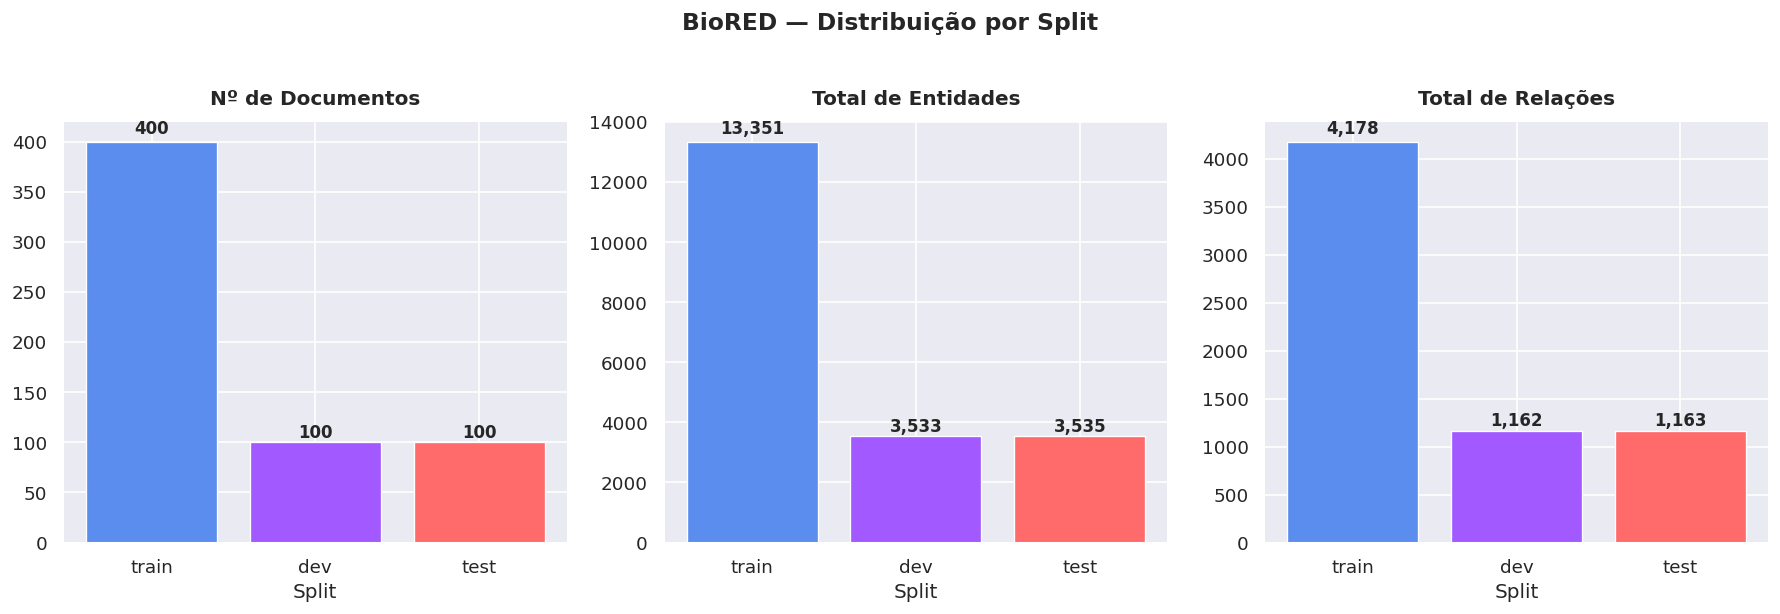

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metricas = ['documentos', 'total_ent', 'total_rel']
titulos  = ['Nº de Documentos', 'Total de Entidades', 'Total de Relações']

for ax, col, titulo in zip(axes, metricas, titulos):
    bars = ax.bar(resumo.index, resumo[col], color=CORES[:3], edgecolor='white', linewidth=0.8)
    ax.set_title(titulo, fontweight='bold', pad=10)
    ax.set_xlabel('Split')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('BioRED — Distribuição por Split', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Distribuição de tokens por documento

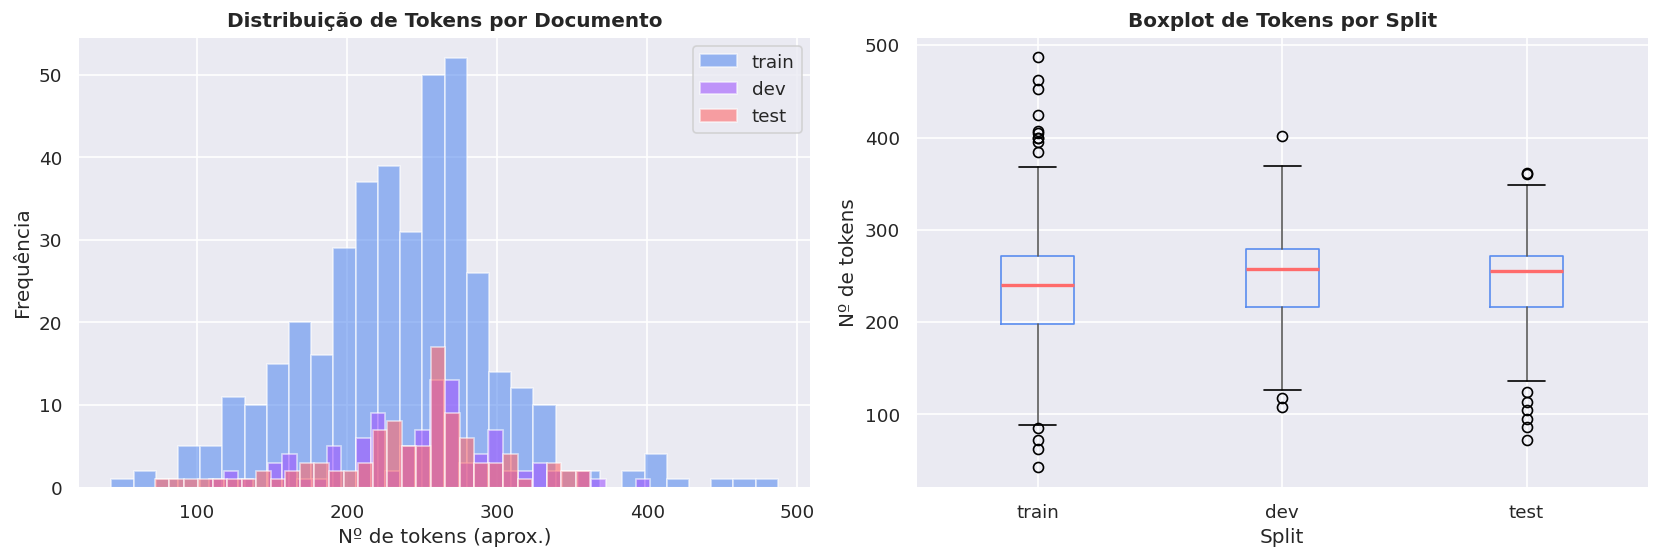

       count   mean   std    min    25%    50%    75%    max
split                                                       
train  400.0  235.6  63.6   43.0  198.0  240.5  271.2  487.0
dev    100.0  249.2  56.3  108.0  216.8  257.5  279.8  402.0
test   100.0  240.9  59.9   72.0  216.5  255.5  272.0  362.0


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
for split, cor in zip(['train','dev','test'], CORES):
    dados = df_docs[df_docs['split']==split]['n_tokens_aprox']
    axes[0].hist(dados, bins=30, alpha=0.6, label=split, color=cor, edgecolor='white')
axes[0].set_title('Distribuição de Tokens por Documento', fontweight='bold')
axes[0].set_xlabel('Nº de tokens (aprox.)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Boxplot
df_docs.boxplot(column='n_tokens_aprox', by='split', ax=axes[1],
                boxprops=dict(color=CORES[0]),
                medianprops=dict(color=CORES[2], linewidth=2))
axes[1].set_title('Boxplot de Tokens por Split', fontweight='bold')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Nº de tokens')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(df_docs.groupby('split', observed=True)['n_tokens_aprox'].describe().round(1))

### 4.3 Tipos de entidade

split,train,dev,test
tipo_entidade,,,
CellLine,103,22,50
ChemicalEntity,2853,822,754
DiseaseOrPhenotypicFeature,3646,982,917
GeneOrGeneProduct,4430,1087,1180
OrganismTaxon,1429,370,393
SequenceVariant,890,250,241


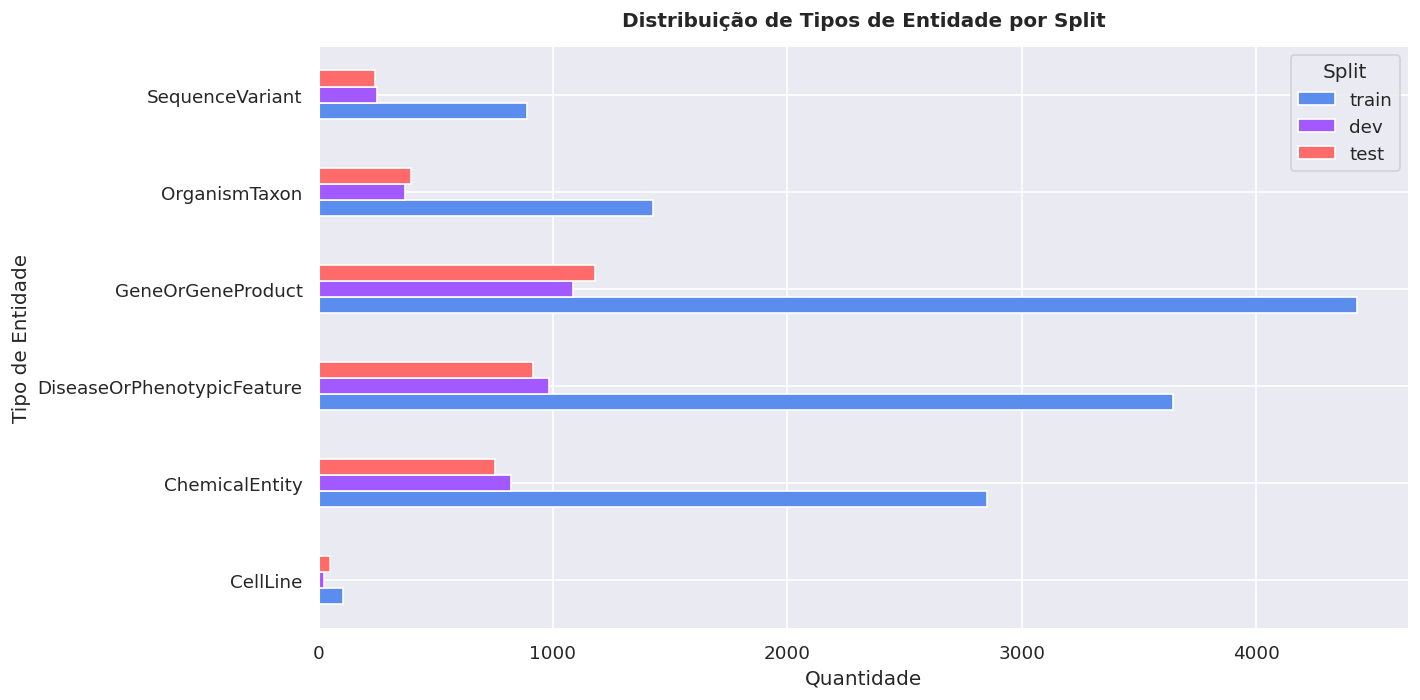

In [18]:
contagem_tipos = (
    df_ent.groupby(['split','tipo_entidade'], observed=True)
    .size()
    .reset_index(name='count')
)

pivot_tipos = contagem_tipos.pivot(index='tipo_entidade', columns='split', values='count').fillna(0).astype(int)
display(pivot_tipos)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_tipos.plot(kind='barh', ax=ax, color=CORES[:3], edgecolor='white')
ax.set_title('Distribuição de Tipos de Entidade por Split', fontweight='bold', pad=12)
ax.set_xlabel('Quantidade')
ax.set_ylabel('Tipo de Entidade')
ax.legend(title='Split')
plt.tight_layout()
plt.show()

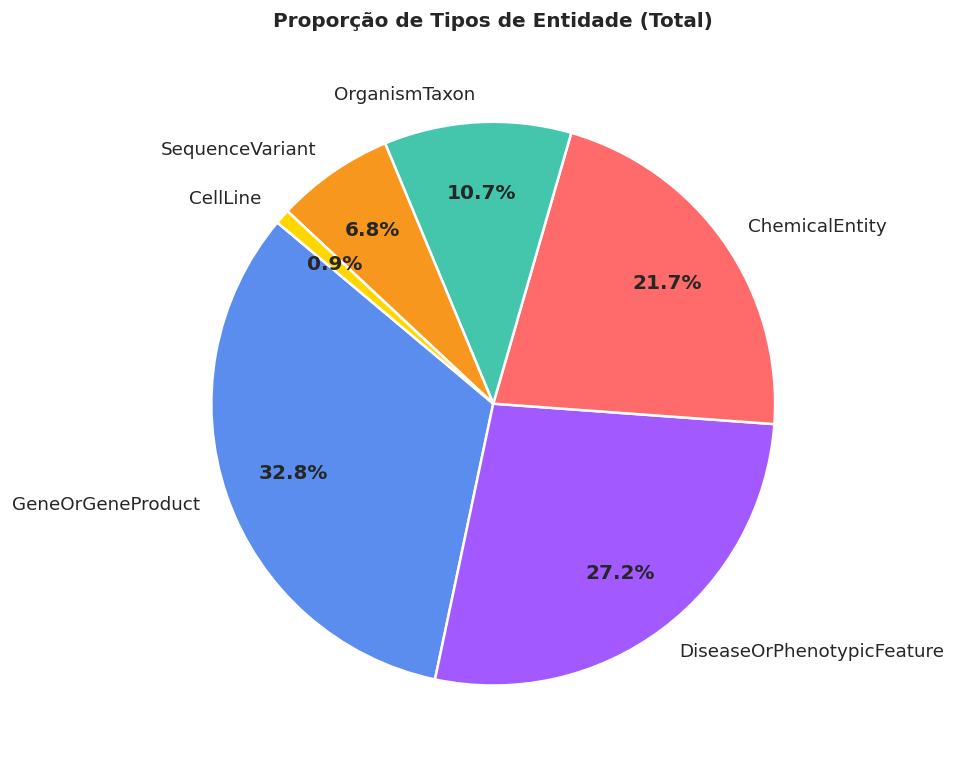

In [19]:
# Pizza — proporção total dos tipos
total_tipos = df_ent['tipo_entidade'].value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    total_tipos.values,
    labels=total_tipos.index,
    autopct='%1.1f%%',
    colors=CORES[:len(total_tipos)],
    startangle=140,
    pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('Proporção de Tipos de Entidade (Total)', fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 4.4 Novel entities — entidades novas vs. conhecidas

In [20]:
# O campo novel_entity marca entidades identificadas pela primeira vez no BioRED
novel_counts = (
    df_ent[df_ent['novel_entity'].isin(['Yes','No'])]
    .groupby(['split','novel_entity'], observed=True)
    .size()
    .reset_index(name='count')
)

if not novel_counts.empty:
    pivot_novel = novel_counts.pivot(index='split', columns='novel_entity', values='count').fillna(0).astype(int)
    display(pivot_novel)

    pivot_novel.plot(kind='bar', color=[CORES[0], CORES[2]], edgecolor='white', figsize=(8,5))
    plt.title('Novel Entities por Split', fontweight='bold')
    plt.xlabel('Split'); plt.ylabel('Quantidade')
    plt.xticks(rotation=0)
    plt.legend(title='Novel Entity?')
    plt.tight_layout()
    plt.show()
else:
    print('Campo novel_entity não encontrado neste dataset — campo pode não estar preenchido.')

Campo novel_entity não encontrado neste dataset — campo pode não estar preenchido.


### 4.5 Tipos de relação

split,train,dev,test,TOTAL
relation_type,,,,
Association,2192,560,635,3387
Positive_Correlation,1089,352,325,1766
Negative_Correlation,763,216,171,1150
Bind,61,19,9,89
Cotreatment,31,10,14,55
Comparison,28,5,6,39
Drug_Interaction,11,0,2,13
Conversion,3,0,1,4


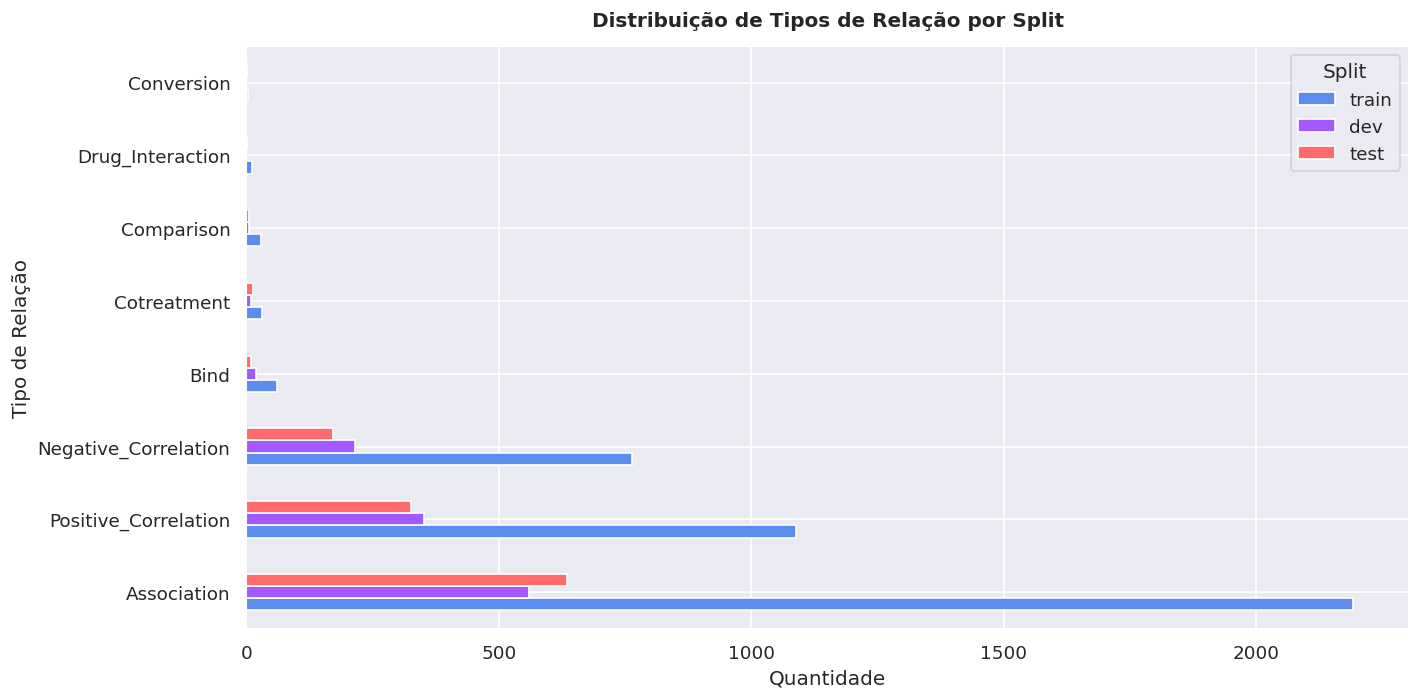

In [21]:
contagem_rel = (
    df_rel.groupby(['split','relation_type'], observed=True)
    .size()
    .reset_index(name='count')
)

pivot_rel = contagem_rel.pivot(index='relation_type', columns='split', values='count').fillna(0).astype(int)
pivot_rel['TOTAL'] = pivot_rel.sum(axis=1)
pivot_rel = pivot_rel.sort_values('TOTAL', ascending=False)
display(pivot_rel)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_rel.drop(columns='TOTAL').plot(kind='barh', ax=ax, color=CORES[:3], edgecolor='white')
ax.set_title('Distribuição de Tipos de Relação por Split', fontweight='bold', pad=12)
ax.set_xlabel('Quantidade')
ax.set_ylabel('Tipo de Relação')
ax.legend(title='Split')
plt.tight_layout()
plt.show()

### 4.6 Pares de tipos de entidade nas relações

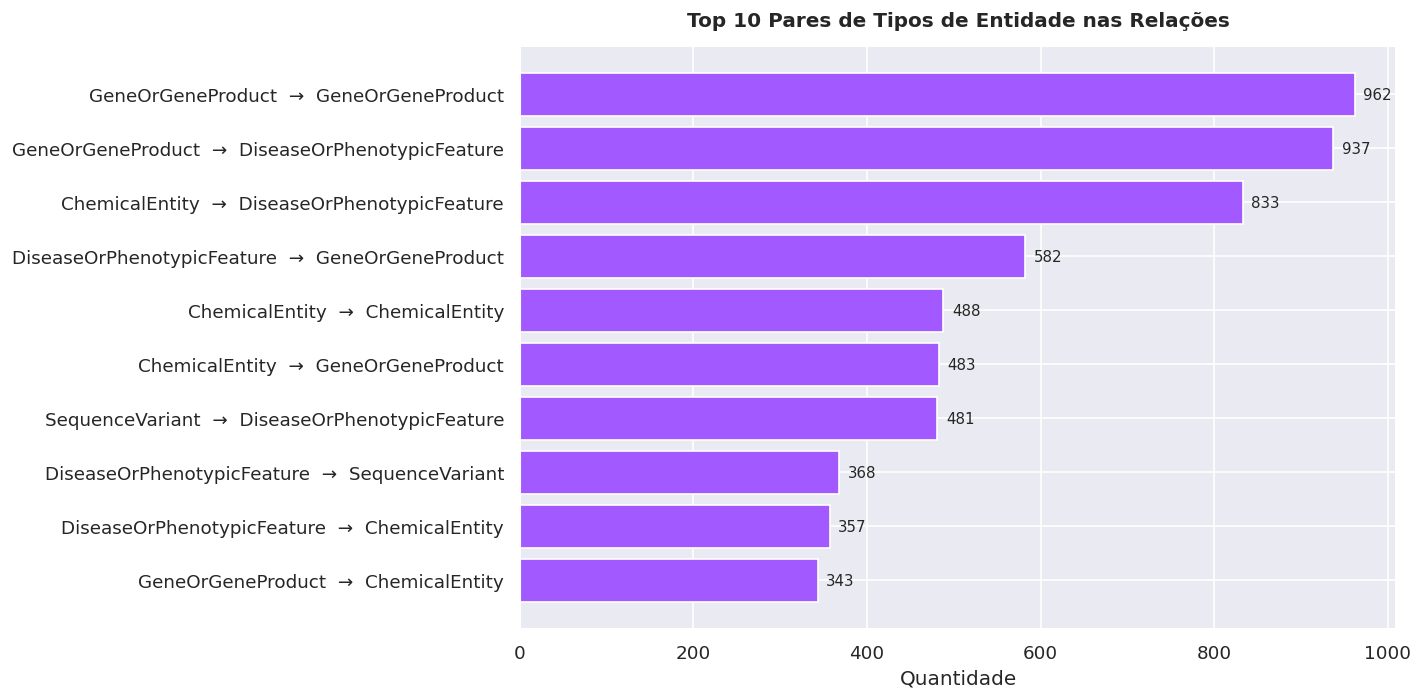

In [22]:
df_rel['par_tipos'] = df_rel['ent1_tipo'] + '  →  ' + df_rel['ent2_tipo']

top_pares = df_rel['par_tipos'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_pares.index[::-1], top_pares.values[::-1], color=CORES[1], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width()+10, bar.get_y()+bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=9)
ax.set_title('Top 10 Pares de Tipos de Entidade nas Relações', fontweight='bold', pad=12)
ax.set_xlabel('Quantidade')
plt.tight_layout()
plt.show()

### 4.7 Heatmap — tipo de relação × par de entidades

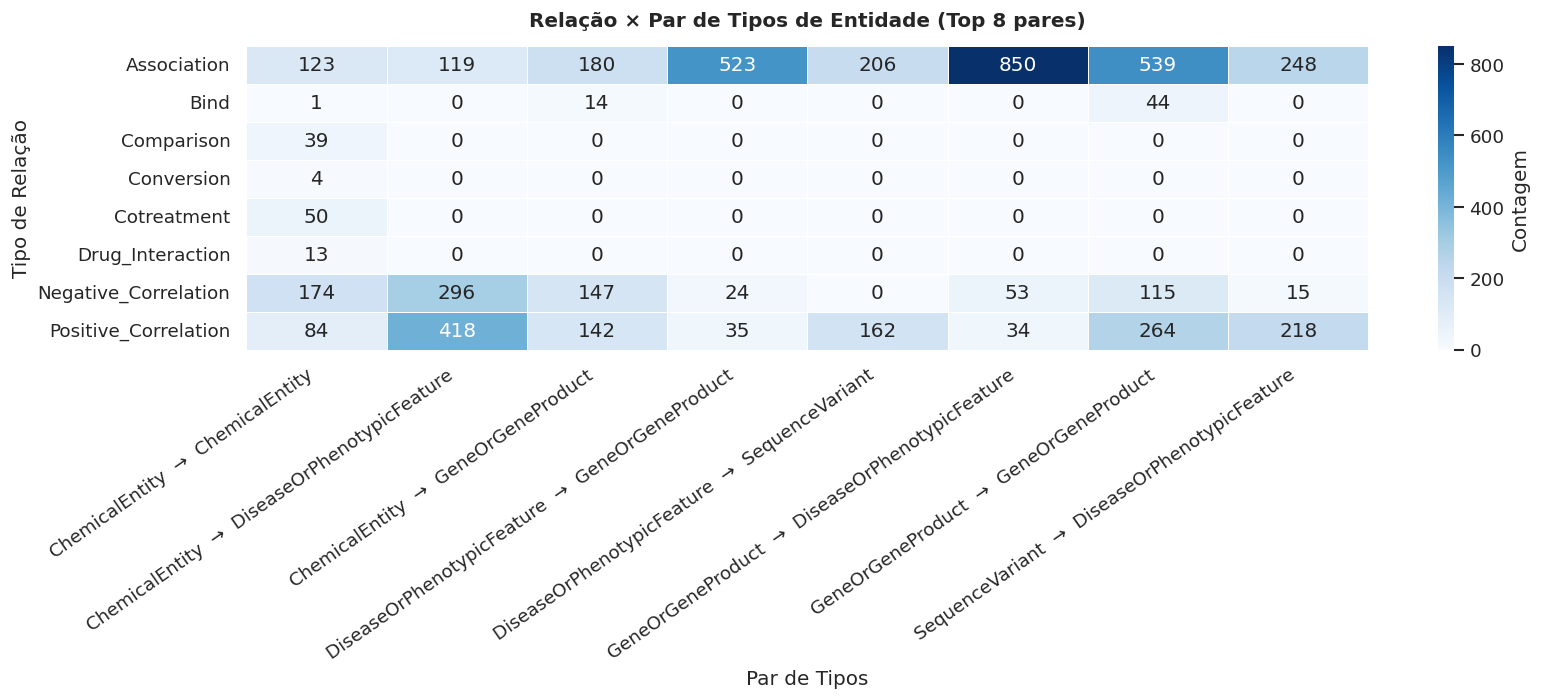

In [23]:
heat_data = (
    df_rel.groupby(['relation_type','par_tipos'], observed=True)
    .size()
    .reset_index(name='count')
)

# Manter só os top-8 pares para legibilidade
top8_pares = df_rel['par_tipos'].value_counts().head(8).index
heat_data  = heat_data[heat_data['par_tipos'].isin(top8_pares)]

pivot_heat = heat_data.pivot(index='relation_type', columns='par_tipos', values='count').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(pivot_heat, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Contagem'})
ax.set_title('Relação × Par de Tipos de Entidade (Top 8 pares)', fontweight='bold', pad=12)
ax.set_xlabel('Par de Tipos')
ax.set_ylabel('Tipo de Relação')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

### 4.8 Documentos com mais relações (top 10)

In [24]:
top_docs = df_docs.nlargest(10, 'n_relacoes')[['document_id','split','n_entidades','n_relacoes','n_tokens_aprox']]
display(top_docs)

,document_id,split,n_entidades,n_relacoes,n_tokens_aprox
524,26937641,test,38,107,215
476,17397547,dev,70,66,402
303,26516699,train,63,60,254
151,25979836,train,69,55,267
179,30836660,train,66,51,340
184,18593936,train,50,51,244
424,26684240,dev,56,51,262
506,20648600,test,53,48,271
301,19463742,train,33,46,126
533,25277705,test,88,45,347


### 4.9 Comprimento dos textos das entidades

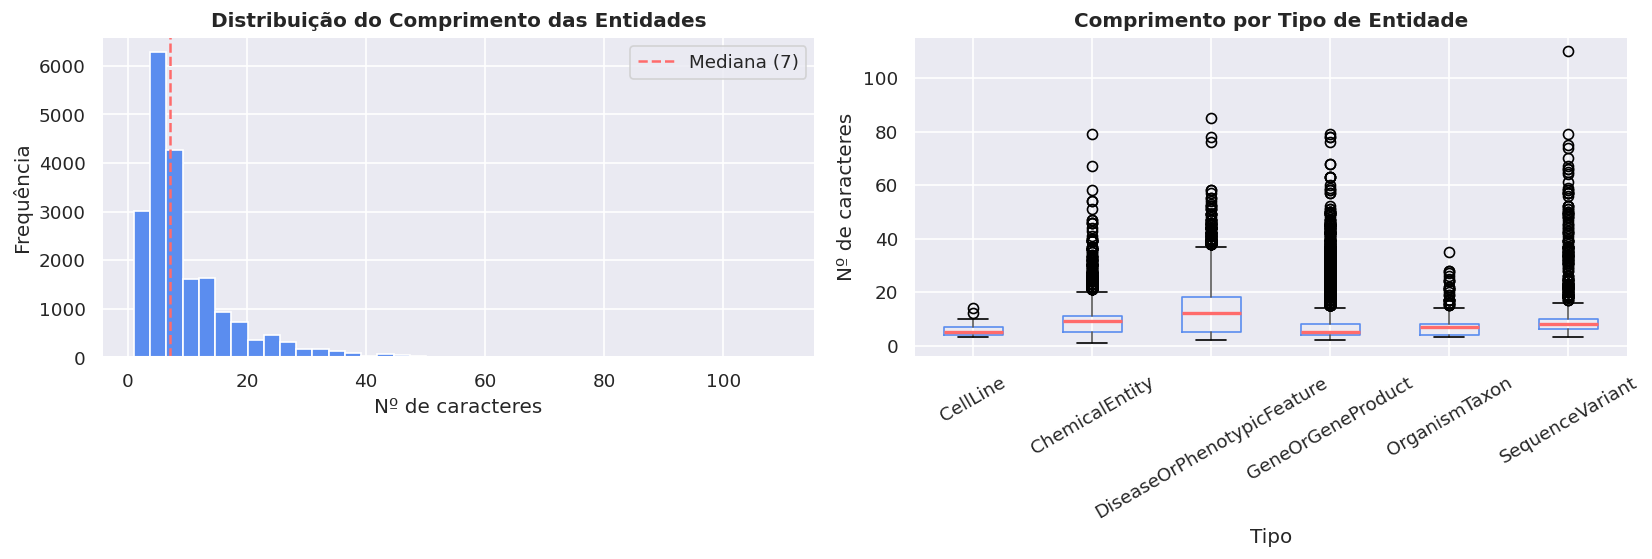

In [25]:
df_ent['len_texto_ent'] = df_ent['texto_entidade'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição geral
axes[0].hist(df_ent['len_texto_ent'], bins=40, color=CORES[0], edgecolor='white')
axes[0].set_title('Distribuição do Comprimento das Entidades', fontweight='bold')
axes[0].set_xlabel('Nº de caracteres')
axes[0].set_ylabel('Frequência')
axes[0].axvline(df_ent['len_texto_ent'].median(), color=CORES[2], linestyle='--', label=f'Mediana ({df_ent["len_texto_ent"].median():.0f})')
axes[0].legend()

# Por tipo
df_ent.boxplot(column='len_texto_ent', by='tipo_entidade', ax=axes[1], rot=30,
               boxprops=dict(color=CORES[0]), medianprops=dict(color=CORES[2], linewidth=2))
axes[1].set_title('Comprimento por Tipo de Entidade', fontweight='bold')
axes[1].set_xlabel('Tipo'); axes[1].set_ylabel('Nº de caracteres')
plt.suptitle('')
plt.tight_layout()
plt.show()

## 5. Diagnóstico de Qualidade dos Dados

In [26]:
print('=== Valores ausentes — df_docs ===')
display(df_docs.isnull().sum().to_frame('nulos'))

print('\n=== Valores ausentes — df_ent ===')
display(df_ent.isnull().sum().to_frame('nulos'))

print('\n=== Valores ausentes — df_rel ===')
display(df_rel.isnull().sum().to_frame('nulos'))

=== Valores ausentes — df_docs ===


,nulos
document_id,0
split,0
texto,0
n_passages,0
n_entidades,0
n_relacoes,0
n_tokens_aprox,0
n_chars,0



=== Valores ausentes — df_ent ===


,nulos
document_id,0
split,0
entity_internal_id,0
identifier,0
texto_entidade,0
tipo_entidade,0
novel_entity,0
offset,0
length,0
passage_offset,0



=== Valores ausentes — df_rel ===


,nulos
document_id,0
split,0
relation_id,0
relation_type,0
novel_relation,0
entity1_id,0
entity2_id,0
ent1_texto,0
ent1_tipo,0
ent2_texto,0


In [27]:
print('=== Documentos duplicados ===')
dup_docs = df_docs[df_docs.duplicated('document_id', keep=False)]
print(f'Documentos com ID duplicado: {dup_docs["document_id"].nunique()}')

print('\n=== Relações com tipo vazio ===')
rel_sem_tipo = df_rel[df_rel['relation_type'].str.strip() == '']
print(f'Relações sem tipo: {len(rel_sem_tipo)}')

print('\n=== Entidades sem identificador ===')
ent_sem_id = df_ent[df_ent['identifier'].str.strip() == '']
print(f'Entidades sem identifier: {len(ent_sem_id)}')

print('\n=== Entidades com texto vazio ===')
ent_sem_txt = df_ent[df_ent['texto_entidade'].str.strip() == '']
print(f'Entidades com texto vazio: {len(ent_sem_txt)}')

print('\n=== Textos de documento muito curtos (< 50 chars) ===')
docs_curtos = df_docs[df_docs['n_chars'] < 50]
print(f'Documentos com texto muito curto: {len(docs_curtos)}')
if len(docs_curtos) > 0:
    display(docs_curtos[['document_id','split','texto','n_chars']])

=== Documentos duplicados ===
Documentos com ID duplicado: 0

=== Relações com tipo vazio ===
Relações sem tipo: 0

=== Entidades sem identificador ===
Entidades sem identifier: 0

=== Entidades com texto vazio ===
Entidades com texto vazio: 0

=== Textos de documento muito curtos (< 50 chars) ===
Documentos com texto muito curto: 0


In [28]:
# Verificar se todos os entity1/entity2 das relações existem nas entidades
ids_ent_validos = set(df_ent['identifier'].unique())

mask_e1_invalido = ~df_rel['entity1_id'].isin(ids_ent_validos)
mask_e2_invalido = ~df_rel['entity2_id'].isin(ids_ent_validos)

print(f'Relações com entity1_id não encontrado nas entidades: {mask_e1_invalido.sum()}')
print(f'Relações com entity2_id não encontrado nas entidades: {mask_e2_invalido.sum()}')

# Verificar relações reflexivas (entidade com ela mesma)
reflexivas = df_rel[df_rel['entity1_id'] == df_rel['entity2_id']]
print(f'Relações reflexivas (e1 == e2): {len(reflexivas)}')

Relações com entity1_id não encontrado nas entidades: 129
Relações com entity2_id não encontrado nas entidades: 173
Relações reflexivas (e1 == e2): 4


## 6. Limpeza e Pré-processamento

### 6.1 Limpeza de texto

In [29]:
def limpar_texto(texto):
    """Normaliza whitespace e remove caracteres de controle."""
    if not isinstance(texto, str):
        return ''
    texto = re.sub(r'[\x00-\x08\x0b\x0c\x0e-\x1f\x7f]', '', texto)  # controle
    texto = re.sub(r'\s+', ' ', texto).strip()                          # whitespace múltiplo
    return texto

def normalizar_entidade(texto):
    """Normaliza texto de entidade: minúsculas sem espaços extras."""
    return limpar_texto(texto).lower()

# Aplicar limpeza
df_docs['texto'] = df_docs['texto'].apply(limpar_texto)
df_ent['texto_entidade'] = df_ent['texto_entidade'].apply(limpar_texto)
df_ent['texto_entidade_norm'] = df_ent['texto_entidade'].apply(normalizar_entidade)
df_rel['texto'] = df_rel['texto'].apply(limpar_texto)
df_rel['ent1_texto'] = df_rel['ent1_texto'].apply(limpar_texto)
df_rel['ent2_texto'] = df_rel['ent2_texto'].apply(limpar_texto)

print(' Limpeza de texto aplicada')

 Limpeza de texto aplicada


### 6.2 Remoção de registros inválidos

In [30]:
print(f'df_docs antes : {len(df_docs)}')
print(f'df_ent  antes : {len(df_ent)}')
print(f'df_rel  antes : {len(df_rel)}')

# Documentos com texto vazio
df_docs = df_docs[df_docs['texto'].str.len() >= 10].reset_index(drop=True)

# Entidades com texto ou tipo vazios
df_ent = df_ent[
    (df_ent['texto_entidade'].str.len() > 0) &
    (df_ent['tipo_entidade'].str.len() > 0)
].reset_index(drop=True)

# Relações com tipo vazio
df_rel = df_rel[df_rel['relation_type'].str.len() > 0].reset_index(drop=True)

# Relações reflexivas
df_rel = df_rel[df_rel['entity1_id'] != df_rel['entity2_id']].reset_index(drop=True)

print(f'\ndf_docs depois: {len(df_docs)}')
print(f'df_ent  depois: {len(df_ent)}')
print(f'df_rel  depois: {len(df_rel)}')

df_docs antes : 600
df_ent  antes : 20419
df_rel  antes : 6503

df_docs depois: 600
df_ent  depois: 20419
df_rel  depois: 6499


### 6.3 Deduplicação

In [31]:
# Entidades duplicadas dentro do mesmo documento e passage
antes = len(df_ent)
df_ent = df_ent.drop_duplicates(
    subset=['document_id','identifier','texto_entidade_norm','offset']
).reset_index(drop=True)
print(f'Entidades removidas por dedup: {antes - len(df_ent)}')

# Relações duplicadas
antes = len(df_rel)
df_rel = df_rel.drop_duplicates(
    subset=['document_id','relation_type','entity1_id','entity2_id']
).reset_index(drop=True)
print(f'Relações removidas por dedup: {antes - len(df_rel)}')

Entidades removidas por dedup: 0
Relações removidas por dedup: 0


### 6.4 Encoding e tipos de dados

In [32]:
# Categorizar colunas de baixa cardinalidade
for col in ['split','tipo_entidade','novel_entity']:
    if col in df_ent.columns:
        df_ent[col] = df_ent[col].astype('category')

for col in ['split','relation_type','ent1_tipo','ent2_tipo']:
    if col in df_rel.columns:
        df_rel[col] = df_rel[col].astype('category')

print('dtypes df_ent:')
print(df_ent.dtypes)
print('\ndtypes df_rel:')
print(df_rel.dtypes)

dtypes df_ent:
document_id              object
split                  category
entity_internal_id       object
identifier               object
texto_entidade           object
tipo_entidade          category
novel_entity           category
offset                    int64
length                    int64
passage_offset            int64
len_texto_ent             int64
texto_entidade_norm      object
dtype: object

dtypes df_rel:
document_id         object
split             category
relation_id         object
relation_type     category
novel_relation      object
entity1_id          object
entity2_id          object
ent1_texto          object
ent1_tipo         category
ent2_texto          object
ent2_tipo         category
texto               object
par_tipos           object
dtype: object


### 6.5 Seleção do subset supervisionado (relações com label)

Para a próxima etapa de treinamento, vamos usar apenas relações que possuam
texto de entidade preenchido nos dois lados e cujo par de tipos seja válido.

In [33]:
# Relações completas (ambas as entidades com texto e tipo preenchidos)
df_rel_clean = df_rel[
    (df_rel['ent1_texto'].str.len() > 0) &
    (df_rel['ent2_texto'].str.len() > 0) &
    (df_rel['ent1_tipo'].astype(str).str.len() > 0) &
    (df_rel['ent2_tipo'].astype(str).str.len() > 0) &
    (df_rel['texto'].str.len() > 0)
].copy().reset_index(drop=True)

print(f'Relações limpas para treinamento: {len(df_rel_clean):,}')
print('\nDistribuição por split:')
display(df_rel_clean['split'].value_counts())
print('\nDistribuição por relation_type:')
display(df_rel_clean['relation_type'].value_counts())

Relações limpas para treinamento: 5,931

Distribuição por split:


,count
split,
train,3828
dev,1113
test,990



Distribuição por relation_type:


,count
relation_type,
Association,3055
Positive_Correlation,1643
Negative_Correlation,1056
Bind,66
Cotreatment,55
Comparison,39
Drug_Interaction,13
Conversion,4


### 6.6 Construção das sentenças de contexto para o modelo

Formato padrão para relation extraction com marcadores de entidade:

```
... [E1] Aspirin [/E1] inhibits [E2] COX-1 [/E2] ...
```

In [34]:
def inserir_marcadores(texto, ent1_texto, ent2_texto):
    """
    Insere marcadores [E1]/[/E1] e [E2]/[/E2] ao redor das entidades no texto.
    Substitui apenas a primeira ocorrência de cada entidade.
    """
    if not isinstance(texto, str):
        return texto

    def escapar(s):
        return re.escape(s) if s else ''

    if ent1_texto and ent1_texto in texto:
        texto = re.sub(escapar(ent1_texto), f'[E1] {ent1_texto} [/E1]', texto, count=1)
    if ent2_texto and ent2_texto in texto:
        texto = re.sub(escapar(ent2_texto), f'[E2] {ent2_texto} [/E2]', texto, count=1)
    return texto

df_rel_clean['texto_marcado'] = df_rel_clean.apply(
    lambda row: inserir_marcadores(row['texto'], row['ent1_texto'], row['ent2_texto']),
    axis=1
)

print('Exemplo de texto marcado:')
print(df_rel_clean['texto_marcado'].iloc[0][:500])

Exemplo de texto marcado:
Hepatocyte nuclear factor-6: associations between genetic variability and type II diabetes and between genetic variability and estimates of insulin secretion. The transcription factor hepatocyte nuclear factor (HNF)-6 is an upstream regulator of several genes involved in the pathogenesis of maturity-onset diabetes of the young. We therefore tested the hypothesis that variability in the [E1] HNF-6 [/E1] gene is associated with subsets of Type II (non-insulin-dependent) diabetes mellitus and estim


### 6.7 Resumo final pós-limpeza

In [35]:
print('=== Resumo pós-limpeza ===')
print(f'Documentos : {len(df_docs):>6,}')
print(f'Entidades  : {len(df_ent):>6,}')
print(f'Relações   : {len(df_rel):>6,}')
print(f'Rel. limpas: {len(df_rel_clean):>6,}')
print()

print('=== Relações limpas por split ===')
display(df_rel_clean.groupby('split', observed=True).agg(
    n_relacoes    = ('relation_id','count'),
    n_tipos_rel   = ('relation_type', 'nunique'),
    n_docs_unicos = ('document_id', 'nunique'),
))

=== Resumo pós-limpeza ===
Documentos :    600
Entidades  : 20,419
Relações   :  6,499
Rel. limpas:  5,931

=== Relações limpas por split ===


,n_relacoes,n_tipos_rel,n_docs_unicos
split,,,
train,3828,8,394
dev,1113,6,98
test,990,8,100


## 7. Exportação dos Artefatos

In [36]:
# Exportar CSVs para uso nas próximas etapas
df_docs.to_csv(f'{PASTA_SAIDA}/documentos.csv',       index=False, encoding='utf-8')
df_ent.to_csv(f'{PASTA_SAIDA}/entidades.csv',         index=False, encoding='utf-8')
df_rel.to_csv(f'{PASTA_SAIDA}/relacoes.csv',          index=False, encoding='utf-8')
df_rel_clean.to_csv(f'{PASTA_SAIDA}/relacoes_limpas.csv', index=False, encoding='utf-8')

# Exportar splits separados (prontos para o modelo)
for split in ['train','dev','test']:
    subset = df_rel_clean[df_rel_clean['split']==split]
    subset.to_csv(f'{PASTA_SAIDA}/relacoes_{split}.csv', index=False, encoding='utf-8')
    print(f'  relacoes_{split}.csv → {len(subset):,} linhas')

print('\n Todos os artefatos exportados para:', PASTA_SAIDA)

  relacoes_train.csv → 3,828 linhas
  relacoes_dev.csv → 1,113 linhas
  relacoes_test.csv → 990 linhas

 Todos os artefatos exportados para: /content/drive/MyDrive/NLP-BioInfo/NLP-BioInfo/dados_limpos


In [37]:
# Salvar mapeamento de labels (para o classificador)
labels = sorted(df_rel_clean['relation_type'].astype(str).unique().tolist())
label2id = {label: idx for idx, label in enumerate(labels)}
id2label  = {idx: label for label, idx in label2id.items()}

with open(f'{PASTA_SAIDA}/label2id.json', 'w') as f:
    json.dump(label2id, f, ensure_ascii=False, indent=2)

print('Labels encontrados:')
for label, idx in label2id.items():
    print(f'  {idx}: {label}')

Labels encontrados:
  0: Association
  1: Bind
  2: Comparison
  3: Conversion
  4: Cotreatment
  5: Drug_Interaction
  6: Negative_Correlation
  7: Positive_Correlation


# Tokenização

 Nesta etapa de tokenização com BioBERT, marcadores de entidade [E1]/[E2] e saída como HuggingFace Dataset.

In [38]:
!pip install transformers datasets torch -q

In [39]:
# 6. Tokenização com BioBERT + Marcadores de Entidade [E1]/[E2]
# Dataset: BioRED | Modelo: dmis-lab/biobert-base-cased-v1.2
# Saída: HuggingFace Dataset salvo em disco

# ── Instalações (rodar uma vez no Colab) ─────────────────────────────────────
# !pip install transformers datasets torch -q

import re
import warnings
import torch
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer

warnings.filterwarnings('ignore')

MODEL_NAME   = "dmis-lab/biobert-base-cased-v1.2"
MAX_LENGTH   = 512          # limite do BERT; textos maiores serão truncados
PASTA_SAIDA  = '/content/drive/MyDrive/NLP-BioInfo/dados_limpos'
DATASET_PATH = f'{PASTA_SAIDA}/biored_tokenizado'

# Tokens especiais de entidade que vamos adicionar ao vocabulário
SPECIAL_TOKENS = ["[E1]", "[/E1]", "[E2]", "[/E2]"]

print(f'Modelo    : {MODEL_NAME}')
print(f'Max tokens: {MAX_LENGTH}')
print(f'Saída     : {DATASET_PATH}')


Modelo    : dmis-lab/biobert-base-cased-v1.2
Max tokens: 512
Saída     : /content/drive/MyDrive/NLP-BioInfo/dados_limpos/biored_tokenizado


In [40]:
# Carregamento do tokenizador + adição dos tokens especiais
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Adiciona [E1], [/E1], [E2], [/E2] como tokens especiais reais
num_added = tokenizer.add_special_tokens(
    {"additional_special_tokens": SPECIAL_TOKENS}
)
print(f'\nTokens especiais adicionados: {num_added}')
print(f'Novo tamanho do vocabulário : {len(tokenizer)}')
#  Lembrar de redimensionar o embedding após carregar o modelo:
#     model.resize_token_embeddings(len(tokenizer))


def inserir_marcadores(texto: str, ent1_texto: str, ent2_texto: str) -> str:
    """
    Insere [E1]…[/E1] ao redor da primeira ocorrência de ent1_texto
    e [E2]…[/E2] ao redor da primeira ocorrência de ent2_texto no texto.

    Exemplo:
        "Aspirin inhibits COX-1"
        → "[E1] Aspirin [/E1] inhibits [E2] COX-1 [/E2]"
    """
    if not isinstance(texto, str):
        return texto

    def escapar(s):
        return re.escape(s) if s else ''

    # Primeira substituição: entidade 1
    if ent1_texto and ent1_texto in texto:
        texto = re.sub(
            escapar(ent1_texto),
            f'[E1] {ent1_texto} [/E1]',
            texto,
            count=1
        )

    # Segunda substituição: entidade 2 (já no texto modificado)
    if ent2_texto and ent2_texto in texto:
        # Garante não marcar dentro de um marcador já inserido
        texto = re.sub(
            r'(?<!\[E1\] )(?<!\[/E1\] )' + escapar(ent2_texto),
            f'[E2] {ent2_texto} [/E2]',
            texto,
            count=1
        )

    return texto

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]


Tokens especiais adicionados: 4
Novo tamanho do vocabulário : 29000


In [41]:
def tokenizar_linha(row: dict) -> dict:
    """
    Recebe uma linha do df_rel (já como dict) e retorna os tensores
    input_ids, attention_mask e token_type_ids, além de metadados úteis.
    """
    texto_marcado = inserir_marcadores(
        row['texto'],
        row['ent1_texto'],
        row['ent2_texto']
    )

    enc = tokenizer(
        texto_marcado,
        max_length=MAX_LENGTH,
        padding='max_length',      # pad até 512
        truncation=True,           # trunca se > 512
        return_tensors=None,       # retorna listas (compatível com HF Dataset)
        return_token_type_ids=True,
    )

    # Posições dos tokens especiais (útil para pooling de entidade)
    ids = enc['input_ids']
    vocab = tokenizer.get_vocab()
    id_e1_open  = vocab.get('[E1]',  -1)
    id_e1_close = vocab.get('[/E1]', -1)
    id_e2_open  = vocab.get('[E2]',  -1)
    id_e2_close = vocab.get('[/E2]', -1)

    def find_pos(token_id):
        return ids.index(token_id) if token_id in ids else -1

    return {
        # ── tensores principais
        'input_ids'         : enc['input_ids'],
        'attention_mask'    : enc['attention_mask'],
        'token_type_ids'    : enc['token_type_ids'],
        # ── posições dos marcadores
        'pos_e1_start'      : find_pos(id_e1_open),
        'pos_e1_end'        : find_pos(id_e1_close),
        'pos_e2_start'      : find_pos(id_e2_open),
        'pos_e2_end'        : find_pos(id_e2_close),
        # ── texto com marcadores
        'texto_marcado'     : texto_marcado,
    }

In [42]:
# Construção do mapa label → id
# df_rel deve estar disponível no escopo
relation_types  = sorted(df_rel['relation_type'].dropna().unique().tolist())
label2id        = {lbl: i for i, lbl in enumerate(relation_types)}
id2label        = {i: lbl for lbl, i in label2id.items()}

print(f'\nTotal de tipos de relação: {len(label2id)}')
for lbl, idx in label2id.items():
    print(f'  {idx:>2}  {lbl}')


#  Processar df_rel e montar colunas finais
print('\nProcessando relações e tokenizando...')

registros = []
for _, row in df_rel.iterrows():
    tok = tokenizar_linha(row.to_dict())
    registros.append({
        # identificadores
        'document_id'   : row['document_id'],
        'split'         : str(row['split']),
        'relation_id'   : row['relation_id'],
        'relation_type' : row['relation_type'],
        'label'         : label2id.get(row['relation_type'], -1),
        'novel_relation': row.get('novel_relation', ''),
        'ent1_texto'    : row['ent1_texto'],
        'ent1_tipo'     : row['ent1_tipo'],
        'ent2_texto'    : row['ent2_texto'],
        'ent2_tipo'     : row['ent2_tipo'],
        # tokenização
        **tok,
    })

df_tok = pd.DataFrame(registros)
print(f'Total de exemplos tokenizados: {len(df_tok):,}')
print(df_tok[['split', 'relation_type', 'label',
              'pos_e1_start', 'pos_e2_start']].head(10))


Total de tipos de relação: 8
   0  Association
   1  Bind
   2  Comparison
   3  Conversion
   4  Cotreatment
   5  Drug_Interaction
   6  Negative_Correlation
   7  Positive_Correlation

Processando relações e tokenizando...
Total de exemplos tokenizados: 6,499
   split         relation_type  label  pos_e1_start  pos_e2_start
0  train           Association      0            80           185
1  train  Positive_Correlation      7           113            28
2  train           Association      0           111           185
3  train                  Bind      1             1            57
4  train  Positive_Correlation      7           122           330
5  train  Positive_Correlation      7           122           342
6  train  Positive_Correlation      7           122           336
7  train  Positive_Correlation      7            15           330
8  train  Positive_Correlation      7            15           342
9  train  Positive_Correlation      7            15           336


In [43]:

#  Verificação: cobertura dos marcadores
cobertura = (
    df_tok[['split', 'pos_e1_start', 'pos_e2_start']]
    .assign(
        e1_encontrada=lambda d: d['pos_e1_start'] > 0,
        e2_encontrada=lambda d: d['pos_e2_start'] > 0,
        ambas        =lambda d: d['e1_encontrada'] & d['e2_encontrada'],
    )
    .groupby('split')[['e1_encontrada', 'e2_encontrada', 'ambas']]
    .mean()
    .mul(100)
    .round(2)
)
print('\n=== Cobertura de marcadores (%) ===')
print(cobertura)


#Converte para HuggingFace DatasetDict e salvar

print('\nMontando HuggingFace DatasetDict...')

def df_split_to_hf(df: pd.DataFrame, split: str) -> Dataset:
    sub = df[df['split'] == split].reset_index(drop=True)
    return Dataset.from_dict({
        'document_id'   : sub['document_id'].tolist(),
        'relation_id'   : sub['relation_id'].tolist(),
        'relation_type' : sub['relation_type'].tolist(),
        'label'         : sub['label'].tolist(),
        'novel_relation': sub['novel_relation'].tolist(),
        'ent1_texto'    : sub['ent1_texto'].tolist(),
        'ent1_tipo'     : sub['ent1_tipo'].tolist(),
        'ent2_texto'    : sub['ent2_texto'].tolist(),
        'ent2_tipo'     : sub['ent2_tipo'].tolist(),
        'input_ids'     : sub['input_ids'].tolist(),
        'attention_mask': sub['attention_mask'].tolist(),
        'token_type_ids': sub['token_type_ids'].tolist(),
        'pos_e1_start'  : sub['pos_e1_start'].tolist(),
        'pos_e1_end'    : sub['pos_e1_end'].tolist(),
        'pos_e2_start'  : sub['pos_e2_start'].tolist(),
        'pos_e2_end'    : sub['pos_e2_end'].tolist(),
        'texto_marcado' : sub['texto_marcado'].tolist(),
    })

dataset_dict = DatasetDict({
    'train': df_split_to_hf(df_tok, 'train'),
    'dev'  : df_split_to_hf(df_tok, 'dev'),
    'test' : df_split_to_hf(df_tok, 'test'),
})

print(dataset_dict)

# Salva no Google Drive
dataset_dict.save_to_disk(DATASET_PATH)
print(f'\n Dataset salvo em: {DATASET_PATH}')

# Salva também o mapeamento de labels
import json
with open(f'{PASTA_SAIDA}/label2id.json', 'w') as f:
    json.dump(label2id, f, indent=2)
with open(f'{PASTA_SAIDA}/id2label.json', 'w') as f:
    json.dump(id2label, f, indent=2)
print(f' label2id.json e id2label.json salvos em: {PASTA_SAIDA}')



=== Cobertura de marcadores (%) ===
       e1_encontrada  e2_encontrada  ambas
split                                     
dev            95.35          95.61  91.73
test           89.85          84.26  79.54
train          96.02          93.08  89.72

Montando HuggingFace DatasetDict...
DatasetDict({
    train: Dataset({
        features: ['document_id', 'relation_id', 'relation_type', 'label', 'novel_relation', 'ent1_texto', 'ent1_tipo', 'ent2_texto', 'ent2_tipo', 'input_ids', 'attention_mask', 'token_type_ids', 'pos_e1_start', 'pos_e1_end', 'pos_e2_start', 'pos_e2_end', 'texto_marcado'],
        num_rows: 4175
    })
    dev: Dataset({
        features: ['document_id', 'relation_id', 'relation_type', 'label', 'novel_relation', 'ent1_texto', 'ent1_tipo', 'ent2_texto', 'ent2_tipo', 'input_ids', 'attention_mask', 'token_type_ids', 'pos_e1_start', 'pos_e1_end', 'pos_e2_start', 'pos_e2_end', 'texto_marcado'],
        num_rows: 1161
    })
    test: Dataset({
        features: ['document_

Saving the dataset (0/1 shards):   0%|          | 0/4175 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1161 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1163 [00:00<?, ? examples/s]


 Dataset salvo em: /content/drive/MyDrive/NLP-BioInfo/dados_limpos/biored_tokenizado
 label2id.json e id2label.json salvos em: /content/drive/MyDrive/NLP-BioInfo/dados_limpos


In [48]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

# 1. Filtrar o DataFrame df_rel_clean para obter apenas os dados do split de treinamento
df_train = df_rel_clean[df_rel_clean['split'] == 'train']

# 2. Extrair a coluna relation_type
y_train = df_train['relation_type']

# 3. Definir as classes e converta para numpy array
classes = np.array(sorted(y_train.unique())) # Convert to numpy array

# 4. Calcular os pesos de classe
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

# 5. Converter o array NumPy resultante para um tensor PyTorch
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32)

print('Pesos de Classe por Tipo de Relação (Tensor PyTorch):')
print(class_weights_tensor)
print(f'Shape do tensor de pesos: {class_weights_tensor.shape}')

Pesos de Classe por Tipo de Relação (Tensor PyTorch):
tensor([  0.2403,   9.2019,  17.0893, 159.5000,  15.4355,  43.5000,   0.6945,
          0.4677])
Shape do tensor de pesos: torch.Size([8])


In [51]:
from torch.utils.data import DataLoader

def custom_collate_fn(batch):
    """
    Função collate personalizada para preencher e empacotar dados tokenizados em tensores PyTorch.
    """
    # Extrair os campos necessários do lote
    input_ids_list        = [item['input_ids'] for item in batch]
    attention_mask_list   = [item['attention_mask'] for item in batch]
    token_type_ids_list   = [item['token_type_ids'] for item in batch]
    label_list            = [item['label'] for item in batch]
    pos_e1_start_list     = [item['pos_e1_start'] for item in batch]
    pos_e1_end_list       = [item['pos_e1_end'] for item in batch]
    pos_e2_start_list     = [item['pos_e2_start'] for item in batch]
    pos_e2_end_list       = [item['pos_e2_end'] for item in batch]


    # Converta listas de IDs para tensores
    input_ids        = torch.tensor(input_ids_list, dtype=torch.long)
    attention_mask   = torch.tensor(attention_mask_list, dtype=torch.long)
    token_type_ids   = torch.tensor(token_type_ids_list, dtype=torch.long)

    # Converta as labels e posições para tensores
    labels           = torch.tensor(label_list, dtype=torch.long)
    pos_e1_start     = torch.tensor(pos_e1_start_list, dtype=torch.long)
    pos_e1_end       = torch.tensor(pos_e1_end_list, dtype=torch.long)
    pos_e2_start     = torch.tensor(pos_e2_start_list, dtype=torch.long)
    pos_e2_end       = torch.tensor(pos_e2_end_list, dtype=torch.long)

    return {
        'input_ids'       : input_ids,
        'attention_mask'  : attention_mask,
        'token_type_ids'  : token_type_ids,
        'labels'          : labels, # Renomeado para 'labels' para compatibilidade com HuggingFace Trainer
        'pos_e1_start'    : pos_e1_start,
        'pos_e1_end'      : pos_e1_end,
        'pos_e2_start'    : pos_e2_start,
        'pos_e2_end'      : pos_e2_end,
    }

# Definir o tamanho do lote
BATCH_SIZE = 16

# Criar os DataLoaders
train_dataloader = DataLoader(
    dataset_dict['train'],
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=custom_collate_fn
)

dev_dataloader = DataLoader(
    dataset_dict['dev'],
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=custom_collate_fn
)

test_dataloader = DataLoader(
    dataset_dict['test'],
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=custom_collate_fn
)

print('DataLoaders criados com sucesso:')
print(f'  Train DataLoader: {len(train_dataloader)} batches de tamanho {BATCH_SIZE}')
print(f'  Dev DataLoader:   {len(dev_dataloader)} batches de tamanho {BATCH_SIZE}')
print(f'  Test DataLoader:  {len(test_dataloader)} batches de tamanho {BATCH_SIZE}')

DataLoaders criados com sucesso:
  Train DataLoader: 261 batches de tamanho 16
  Dev DataLoader:   73 batches de tamanho 16
  Test DataLoader:  73 batches de tamanho 16


In [52]:
print('\n=== Verificando a estrutura dos DataLoaders ===')

# Função auxiliar para inspecionar um lote
def inspect_batch(dataloader, split_name):
    batch = next(iter(dataloader))
    print(f'\n--- {split_name} Batch ---')
    print(f'Número de itens no lote: {len(batch["input_ids"])}')
    print(f'Chaves do lote: {list(batch.keys())}')
    for key, value in batch.items():
        print(f'  {key:<15}: dtype={value.dtype}, shape={value.shape}')
        if key == 'labels':
            print(f'    Labels range: [{value.min().item()}, {value.max().item()}]')

# Inspecionar um lote de cada DataLoader
inspect_batch(train_dataloader, 'Train')
inspect_batch(dev_dataloader, 'Dev')
inspect_batch(test_dataloader, 'Test')

print('\nVerificação dos DataLoaders concluída.')


=== Verificando a estrutura dos DataLoaders ===

--- Train Batch ---
Número de itens no lote: 16
Chaves do lote: ['input_ids', 'attention_mask', 'token_type_ids', 'labels', 'pos_e1_start', 'pos_e1_end', 'pos_e2_start', 'pos_e2_end']
  input_ids      : dtype=torch.int64, shape=torch.Size([16, 512])
  attention_mask : dtype=torch.int64, shape=torch.Size([16, 512])
  token_type_ids : dtype=torch.int64, shape=torch.Size([16, 512])
  labels         : dtype=torch.int64, shape=torch.Size([16])
    Labels range: [0, 7]
  pos_e1_start   : dtype=torch.int64, shape=torch.Size([16])
  pos_e1_end     : dtype=torch.int64, shape=torch.Size([16])
  pos_e2_start   : dtype=torch.int64, shape=torch.Size([16])
  pos_e2_end     : dtype=torch.int64, shape=torch.Size([16])

--- Dev Batch ---
Número de itens no lote: 16
Chaves do lote: ['input_ids', 'attention_mask', 'token_type_ids', 'labels', 'pos_e1_start', 'pos_e1_end', 'pos_e2_start', 'pos_e2_end']
  input_ids      : dtype=torch.int64, shape=torch.Size(